In [2]:
!git clone --branch refactor-process-data-multidim-series-normalization --single-branch https://github.com/BitKnigth/cryptobot-enviroment.git src
!pip install optuna ewtpy ta

Cloning into 'src'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 166 (delta 70), reused 145 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 3.20 MiB | 29.29 MiB/s, done.
Resolving deltas: 100% (70/70), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.0 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=b29e778ed7c4716fa84f5907599625621e5cdff2609363c4be83e29ee771c891
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import optuna
import ta
from src.src import pre_process_data_multidim,prepare_data, prepare_data_up_down, prepare_data_multidim, read_yfinance_crypto_data, full_evaluation_flow, optimize_hyperparameters, split_data_set, model_builder, model_builder_binary_class

In [15]:
# Fetch Ripple price data
df = read_yfinance_crypto_data("XRP-USD", "max", "1d")

In [16]:
#Calculate TAs
rsi = ta.momentum.RSIIndicator(close=df["Close"]).rsi()
bb = ta.volatility.BollingerBands(close=df["Close"], window=90, window_dev=2)
df["rsi"] = rsi
# Add Bollinger Bands to DataFrame
df["bb_m"] = bb.bollinger_mavg() # Middle Band (SMA)
df["bb_u"] = bb.bollinger_hband() # Upper Band
df["bb_l"] = bb.bollinger_lband() # Lower Band

df.bfill(inplace=True)

In [17]:

scaler = MinMaxScaler()

[
    [train_date_series, train_data, normalized_data],
    [test_date_series, testData, normalized_test_data]
] = pre_process_data_multidim(
    [
        df["Close"],
        df["Volume"],
        df["rsi"],
        df["bb_m"], # Middle Band (SMA)
        df["bb_u"], # Upper Band
        df["bb_l"]
    ], scaler)

print(f"Train Data: {train_data.shape}\nTest Data: {testData.shape}")

test_target = testData
print(f"Train Target: {train_data.shape}\nTest Data: {test_target.shape}")

[array([[0.21748801],
       [0.20648301],
       [0.21043   ],
       ...,
       [2.53542495],
       [2.38231492],
       [2.40064549]]), array([[  147916992],
       [  141032992],
       [  134503008],
       ...,
       [14154535566],
       [ 7724989243],
       [ 7509500416]]), array([[68.35695118],
       [68.35695118],
       [68.35695118],
       ...,
       [39.08817708],
       [35.12062821],
       [35.95872457]]), array([[0.2070364 ],
       [0.2070364 ],
       [0.2070364 ],
       ...,
       [2.74725294],
       [2.61663194],
       [2.51986723]]), array([[0.22054249],
       [0.22054249],
       [0.22054249],
       ...,
       [3.12345152],
       [2.95336568],
       [2.75622866]]), array([[0.19353031],
       [0.19353031],
       [0.19353031],
       ...,
       [2.37105436],
       [2.27989819],
       [2.2835058 ]])]
(2647, 6)
(2647, 6)
Cutoff:  794
Cutoff:  794
Cutoff:  794
Train Data: (1853, 6)
Test Data: (794, 6)
Train Target: (1853, 6)
Test Data: (794, 6)


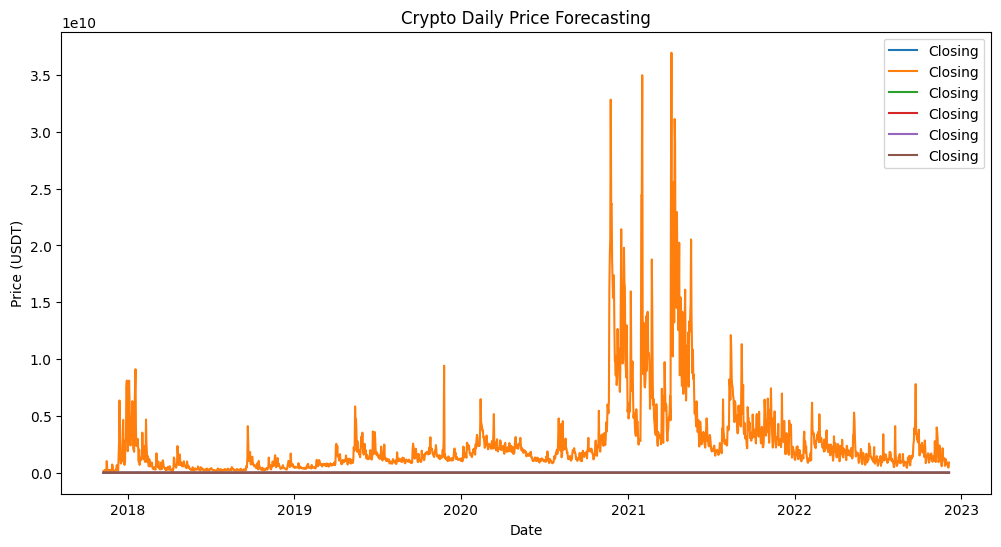

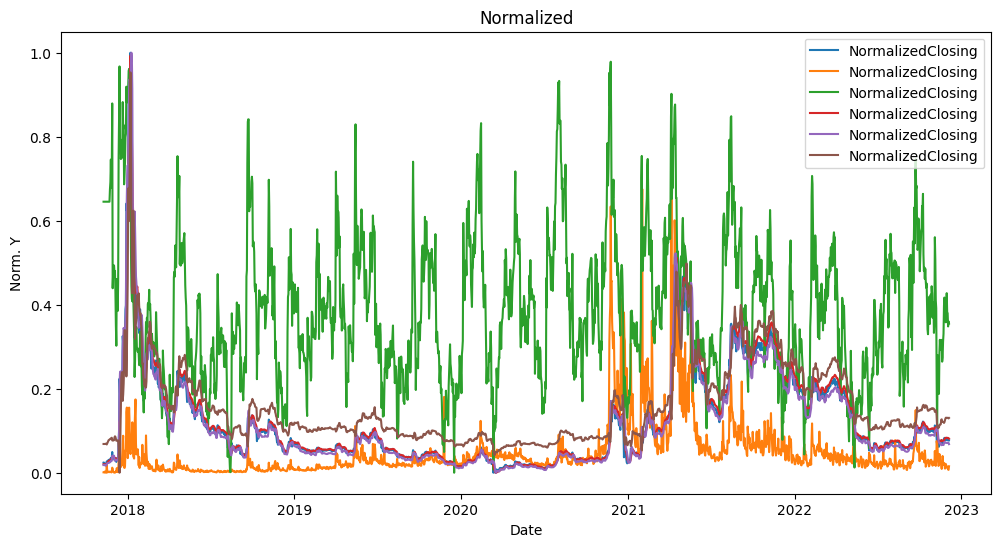

In [18]:
# Plot train data
plt.figure(figsize=(12, 6))
plt.plot(train_date_series, train_data[:], label='Closing')
plt.title('Crypto Daily Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(train_date_series, normalized_data, label='NormalizedClosing')
plt.title('Normalized')
plt.xlabel('Date')
plt.ylabel('Norm. Y')
plt.legend()
plt.show()

In [19]:
# Prepare data for each EWT component
seq_len = 90
print(normalized_data.shape)
X, y, train_data, train_date_series = prepare_data_multidim(
    normalized_data,
    train_data,
    train_date_series,
    seq_len
)

print(y.shape, X.shape, train_date_series.shape, train_data.shape)

(1853, 6)
(1853, 6) (1853, 6)
(1763, 1) (1763, 90, 6) (1763,) (1763, 6)


In [20]:
y


array([[0.72389501],
       [0.80526298],
       [0.95442802],
       ...,
       [0.388147  ],
       [0.390735  ],
       [0.389584  ]])

In [21]:
# The training data is separated in a train set to train each opt iteration and a validation one
# to validate each iteration.

x_train, x_val = split_data_set(X, 0.3)
y_train, y_val = split_data_set(y, 0.3)

print(x_train.shape, x_val.shape)

Cutoff:  528
Cutoff:  528
(1235, 90, 6) (528, 90, 6)


In [22]:
model = model_builder(
    264,
    0.22247614754696465,
    60,
    0.00001,
    x_train[0].shape
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=16,
    epochs=136,
    verbose=1
)

Epoch 1/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0774 - val_loss: 0.0147
Epoch 2/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0113 - val_loss: 0.0121
Epoch 3/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0091 - val_loss: 0.0065
Epoch 4/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0079 - val_loss: 0.0048
Epoch 5/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0081 - val_loss: 0.0066
Epoch 6/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0086 - val_loss: 0.0041
Epoch 7/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 8/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - val_loss: 0.0041
Epoch 9/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0094 - val_loss: 0.0043
Epoch 10/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 11/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - val_loss: 0.0036
Epoch 12/136
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

(794, 6) (794, 6)
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


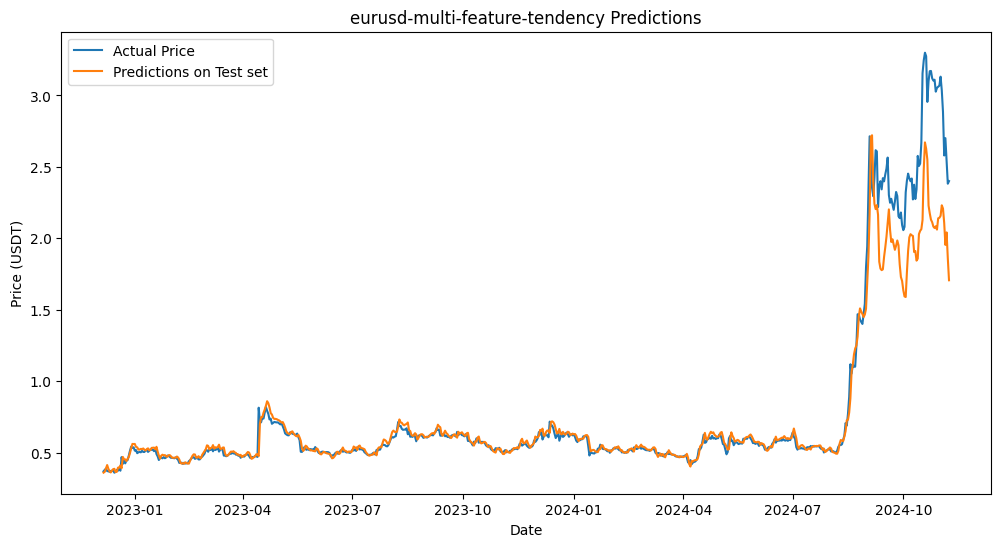

Model: eurusd-multi-feature-tendency
RMSE: 0.1896
MAE: 0.0700
MAPE: 4.8723
R2 Score: 0.9063


{'RMSE': 0.18964121871031958,
 'MAE': 0.0699687505310232,
 'MAPE': 4.872286081519466,
 'R2': 0.9062671930938148}

In [25]:
full_evaluation_flow(
    model,
    prepare_data_multidim,
    normalized_test_data,
    testData,
    test_date_series,
    seq_len,
    "eurusd-multi-feature-tendency"
)

In [24]:
!mkdir -p saved_models
model.save("saved_models/eurusd-multi-feat-tendency-p90-2L.keras")